<a href="https://colab.research.google.com/github/edwardcalvinvazc-maker/cancer_detection_classifier/blob/main/cancer_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.ensemble import (HistGradientBoostingClassifier,RandomForestClassifier,StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline as pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)
cancer_dataset = pd.read_csv('/content/cancer_dataset.csv')

In [120]:
cancer_dataset.shape

(569, 33)

In [121]:
target_column = 'diagnosis'

In [122]:
# Map 'M' to 1 and 'B' to 0 for the target column, and assign to y
y = cancer_dataset[target_column].map({'M': 1, 'B': 0})

X = cancer_dataset.drop(columns=[target_column, 'id', 'Unnamed: 32'])

# Display the first few rows of X and y to confirm the changes
display(X.head())
display(y.head())


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,diagnosis
0,1
1,1
2,1
3,1
4,1


In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [124]:
display(X_train.head())

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
251,11.50,18.45,73.28,407.4,0.09345,0.05991,0.026380,0.020690,0.1834,0.05934,...,12.97,22.46,83.12,508.9,0.1183,0.10490,0.08105,0.06544,0.2740,0.06487
373,20.64,17.35,134.80,1335.0,0.09446,0.10760,0.152700,0.089410,0.1571,0.05478,...,25.37,23.17,166.80,1946.0,0.1562,0.30550,0.41590,0.21120,0.2689,0.07055
211,11.84,18.94,75.51,428.0,0.08871,0.06900,0.026690,0.013930,0.1533,0.06057,...,13.30,24.99,85.22,546.3,0.1280,0.18800,0.14710,0.06913,0.2535,0.07993
52,11.94,18.24,75.71,437.6,0.08261,0.04751,0.019720,0.013490,0.1868,0.06110,...,13.10,21.33,83.67,527.2,0.1144,0.08906,0.09203,0.06296,0.2785,0.07408
315,12.49,16.85,79.19,481.6,0.08511,0.03834,0.004473,0.006423,0.1215,0.05673,...,13.34,19.71,84.48,544.2,0.1104,0.04953,0.01938,0.02784,0.1917,0.06174


In [118]:
##Estimator Model 1

rfc_clf = RandomForestClassifier(n_estimators=300, random_state = 42,max_depth=None,min_samples_leaf=2,n_jobs=-1,)

##Estimator Model 2

hgb_clf = HistGradientBoostingClassifier(max_iter=300,random_state=42,learning_rate=0.05,max_depth=None)

##Base Model Using Model 1 & 2

base_estimators = [("rfc_clf",rfc_clf),("hgb_clf",hgb_clf)]

##Final Model LogisticRegression

final_estimator = LogisticRegression(max_iter=2000)

##Stacking the Models

stack_clf = StackingClassifier(estimators=base_estimators,stack_method="predict_proba",final_estimator=final_estimator,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42))

stack_clf.fit(X_train,y_train)

stack_clf.score(X_train,y_train)



1.0

In [125]:
pipeline = Pipeline([("scaler", StandardScaler()),("stack", stack_clf),])
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('stack',
                 StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                    estimators=[('rfc_clf',
                                                 RandomForestClassifier(min_samples_leaf=2,
                                                                        n_estimators=300,
                                                                        n_jobs=-1,
                                                                        random_state=42)),
                                                ('hgb_clf',
                                                 HistGradientBoostingClassifier(learning_rate=0.05,
                                                                                max_iter=300,
                                                                                random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=2000),
                                    stack_method='predict_proba'))])

In [208]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
new_threshold = 0.05    #<------Change Threshold
y_pred_threshold = (y_proba >= new_threshold).astype(int)

In [209]:
print("\n===Stacking Classifier===")
print("Accuracy",accuracy_score(y_test,y_pred_threshold))
print("ROC AUC",roc_auc_score(y_test,y_pred_threshold))
print("\nClassifier Report : \n",classification_report(y_test,y_pred_threshold))


===Stacking Classifier===
Accuracy 0.9370629370629371
ROC AUC 0.9500000000000001

Classifier Report : 
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        90
           1       0.85      1.00      0.92        53

    accuracy                           0.94       143
   macro avg       0.93      0.95      0.93       143
weighted avg       0.95      0.94      0.94       143



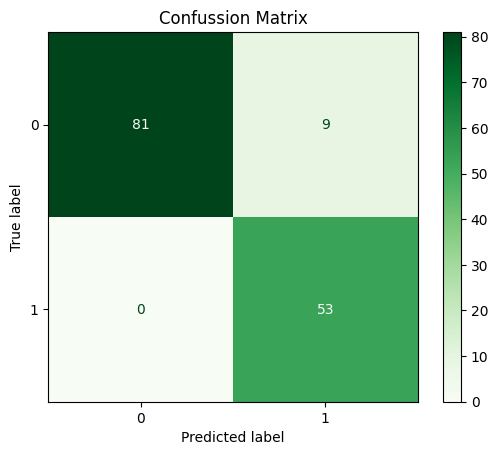

Accruacy of the model :  93.7062937062937


<Figure size 640x480 with 0 Axes>

In [210]:
cm = confusion_matrix(y_test,y_pred_threshold)
ConfusionMatrixDisplay(cm).plot(cmap="Greens")
plt.title("Confussion Matrix")
plt.show()
plt.savefig("Confussion Matrix.png")
print("Accruacy of the model : ",accuracy_score(y_test,y_pred_threshold)*100)

### Model Evaluation (with Cost-Sensitive Threshold)

Now, let's re-evaluate the model's performance using the predictions (`y_pred_threshold`) that were adjusted based on the cost-sensitive threshold. This will give us a clear picture of the trade-offs made to reduce costly false negatives.


=== Model Evaluation with Cost-Sensitive Threshold ===
Accuracy Score: 0.9371
ROC AUC Score: 0.9500

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        90
           1       0.85      1.00      0.92        53

    accuracy                           0.94       143
   macro avg       0.93      0.95      0.93       143
weighted avg       0.95      0.94      0.94       143


Confusion Matrix:


,Predicted Negative (0),Predicted Positive (1)
Actual Negative (0),81,9
Actual Positive (1),0,53


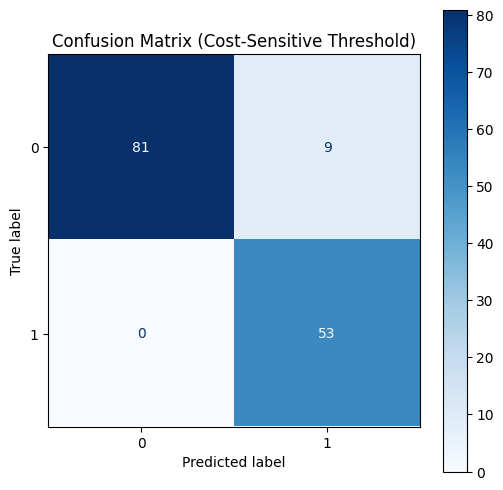

In [211]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n=== Model Evaluation with Cost-Sensitive Threshold ===")

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred_threshold)
print(f"Accuracy Score: {accuracy:.4f}")

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_threshold) # Using y_pred_threshold for binary prediction here
print(f"ROC AUC Score: {roc_auc:.4f}")

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_threshold)
print("\nConfusion Matrix:")
display(pd.DataFrame(cm, index=['Actual Negative (0)', 'Actual Positive (1)'], columns=['Predicted Negative (0)', 'Predicted Positive (1)']))

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm).plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix (Cost-Sensitive Threshold)')
plt.grid(False)
plt.show()

In [212]:
# The confusion matrix (cm) was already computed in the previous cell 'abf55608'
# cm is structured as: [[TN, FP], [FN, TP]]
# So, cm[1, 0] gives the count of False Negatives.

false_negatives = cm[1, 0]

print(f"Number of Actual Positives Predicted as Negative (False Negatives): {false_negatives}")

if false_negatives > 0:
    print(f"Yes, the model predicted {false_negatives} actual positive cases as negative, which are False Negatives. This means {false_negatives} cancer cases were missed by the model at this threshold.")
else:
    print("No, the model did not predict any actual positive cases as negative (0 False Negatives) at this threshold.")
    print("Accruacy of the model : ",accuracy_score(y_test,y_pred_threshold)*100)

Number of Actual Positives Predicted as Negative (False Negatives): 0
No, the model did not predict any actual positive cases as negative (0 False Negatives) at this threshold.
Accruacy of the model :  93.7062937062937
